In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

data = np.loadtxt("boston_housing.csv", delimiter=",", skiprows=1)

v = data[:,[1,3]]

In [15]:
def standardize (v):

    data_padr = np.zeros(v.shape)

    media0 = np.mean(v[:,0])
    desv0 = np.std(v[:,0])
    data_padr[:,0] = (v[:,0] - media0) / desv0

    media1 = np.mean(v[:,1])
    desv1 = np.std(v[:,1])
    data_padr[:,1] = (v[:,1] - media1) / desv1

    return (data_padr)

In [16]:
data_padr = standardize(v)

X_true = data_padr[:,0]
y_true = data_padr[:,1]

df_pandas = pd.DataFrame (data_padr, columns = ['X','Y'])

X_p = df_pandas['X']
y_p = df_pandas['Y']

In [17]:
def regressao_linear(X, y):
    X_ = np.mean(X)
    y_ = np.mean(y)

    w1 = (np.sum((X-X_)*(y-y_)))/np.sum((X-X_)**2)
    w0 = y_- (w1*X_)

    return (w0, w1)

In [18]:
w0, w1 = regressao_linear(X_true, y_true)
print(w0, w1)

-5.464451518822262e-17 -0.7606700599726768


In [19]:
modelo = smf.ols ('Y ~ X', penalty = None, data = df_pandas)
modelo = modelo.fit()
modelo.summary()

print (modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.579
Model:                            OLS   Adj. R-squared:                  0.578
Method:                 Least Squares   F-statistic:                     668.7
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           1.93e-93
Time:                        15:42:54   Log-Likelihood:                -482.56
No. Observations:                 489   AIC:                             969.1
Df Residuals:                     487   BIC:                             977.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.361e-17      0.029   4.63e-16      1.0

C:\Users\David\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\base\model.py:130: ValueWarning: unknown kwargs ['penalty']
  warnings.warn(msg, ValueWarning)


In [20]:
def predict_univariate(X, w0, w1):
    y_predict = w0 + (w1*X)

    return y_predict

def MSE (y_true, y_predict):
    mse = np.mean ((y_true - y_predict)**2)

    return mse

def R2 (y_true, y_predict):
    r2 = 1 - np.sum((y_true-y_predict)**2) / np.sum((y_true-(np.mean(y_true)))**2)

    return r2

In [21]:
y_predict = predict_univariate(X_true, w0, w1)
print ("Predições:",y_predict)

Predições: [ 8.55812310e-01  4.08532932e-01  9.57955437e-01  1.07515124e+00
  8.18180631e-01  8.31082921e-01  5.47951539e-02 -6.67733073e-01
 -1.82678877e+00 -4.47318956e-01 -8.07507878e-01 -3.55208744e-02
 -2.97867433e-01  5.03149723e-01  2.88111560e-01  4.80570716e-01
  6.83781780e-01 -1.86047588e-01  1.34359274e-01  1.78442097e-01
 -8.68793755e-01 -9.57315600e-02 -6.21499868e-01 -7.46222002e-01
 -3.61303691e-01 -3.83882698e-01 -2.01100260e-01 -4.66672391e-01
  1.50130938e-02  1.03178741e-01 -1.03867390e+00 -1.07914857e-02
 -1.58809641e+00 -5.81717808e-01 -7.95680779e-01  3.50472628e-01
  1.64464617e-01  4.48314992e-01  3.02089041e-01  9.26774904e-01
  1.17836955e+00  8.70864981e-01  7.66571472e-01  5.91315370e-01
  3.64450108e-01  2.93487514e-01 -1.30137666e-01 -6.30101394e-01
 -1.92140556e+00 -3.50551783e-01 -5.48743091e-02  3.77352398e-01
  8.23556585e-01  4.84871479e-01 -2.00025069e-01  8.74090554e-01
  7.70872236e-01  9.66556964e-01  6.53676437e-01  3.99931405e-01
 -2.26185847e-

In [22]:
mse = MSE (y_true, y_predict)
print ("MSE:", mse)

MSE: 0.4213810598611643


In [23]:
r2 = R2 (y_true, y_predict)
print ("R2:", r2)

R2: 0.5786189401388357


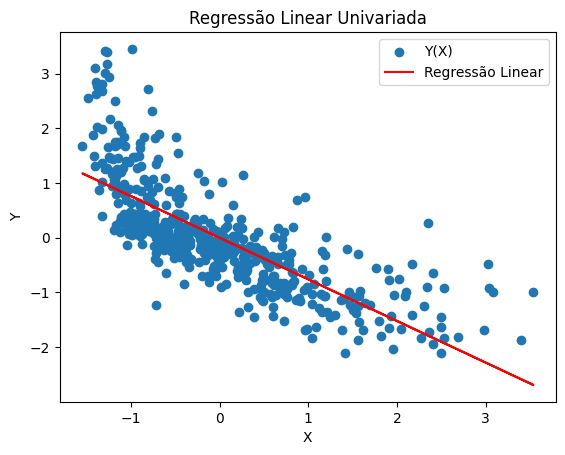

In [24]:
plt.scatter(X_true, y_true, label = "Y(X)")
plt.plot(X_true, y_predict, color='red', label = "Regressão Linear")
plt.title("Regressão Linear Univariada")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()